In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import  TensorDataset, DataLoader

In [22]:
# Loada MNIST Dataset

transform = transforms.Compose([transforms.ToTensor()])

train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset  = torchvision.datasets.MNIST(root='/data', train=False, download=True, transform=transform)

In [23]:
# DataLoader 

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=64, shuffle=True)

In [24]:
# Build MLP Model 

class MLP(nn.Module):
    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(
            nn.Flatten(),
            
            nn.Linear(784, 256),
            nn.ReLU(),

            nn.Linear(256, 128),
            nn.ReLU(),

            nn.Linear(128, 10)
        )
    def forward(self, x):
        return self.model(x)

In [25]:
model = MLP()

criteria = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [41]:
# Training Loop

epochs = 5

for epoch in range(epochs):
    model.train()
    for xb, yb in train_loader:      
        output  = model(xb)     # Forward Propagation
        loss = criteria(output, yb) # find Loss 
        optimizer.zero_grad() 
        loss.backward()   # Backpropagation
        optimizer.step()    # Update Optim

    print(f"epochs{epoch+1}, loss {loss.item()}")

epochs1, loss 0.05033028870820999
epochs2, loss 0.04681042209267616
epochs3, loss 0.1047409325838089
epochs4, loss 0.0266207717359066
epochs5, loss 0.04929749295115471


In [42]:
# Evaluation

correct = 0
total   = 0

model.eval()
with torch.no_grad():
    for xb, yb in test_loader:
        output = model(xb)  # Forward Propagation
        _, predicted = torch.max(output, 1)

        total += yb.size(0)
        correct += (predicted == yb).sum().item()

    print(f"Accuracy:", 100*correct/total)

Accuracy: 97.93


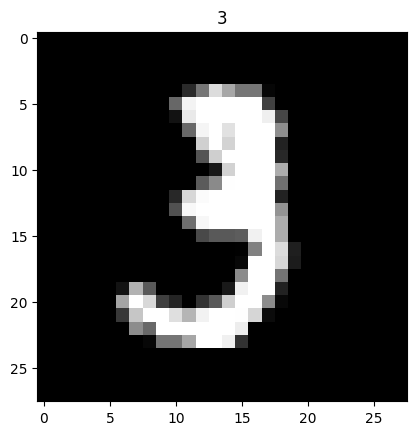

In [45]:
import matplotlib.pyplot as plt

xb, yb = train_dataset[10]

plt.imshow(xb.squeeze(), cmap="gray")
plt.title(yb)
plt.show()